# Phát hiện bình luận độc hại tiếng Việt với PhoBERT trên dataset ViHSD

Notebook này triển khai đề tài **"Ứng dụng kỹ thuật Transformer trong bài toán phát hiện bình luận độc hại"**,
áp dụng cho tiếng Việt bằng cách fine-tune **PhoBERT** (`vinai/phobert-base`) trên dataset **ViHSD**
(Vietnamese Hate Speech Detection).

## Pipeline

1. Cài đặt môi trường
2. Tải & khám phá dataset (EDA)
3. Tiền xử lý văn bản (làm sạch + tách từ tiếng Việt)
4. Tokenize bằng PhoBERT tokenizer
5. Xử lý mất cân bằng lớp (class imbalance)
6. Fine-tune PhoBERT cho bài toán phân loại 3 lớp
7. Đánh giá chi tiết (classification report, confusion matrix, error analysis)
8. Lưu model & demo inference

## Về dataset ViHSD

- 33.400 bình luận mạng xã hội tiếng Việt, gán nhãn thủ công: **CLEAN** (0), **OFFENSIVE** (1), **HATE** (2).
- Nguồn: Luu et al., *"A Large-Scale Dataset for Hate Speech Detection on Vietnamese Social Media Texts"*, 2021.
- Repo: https://github.com/sonlam1102/vihsd — **chỉ dùng cho mục đích nghiên cứu**, vui lòng trích dẫn paper gốc khi sử dụng (xem BibTeX ở cuối notebook).

> **Lưu ý phần cứng:** notebook chạy local. Nếu máy có Apple Silicon, PyTorch sẽ tự dùng backend **MPS** để tăng tốc;
> nếu không có GPU/MPS, quá trình fine-tune trên CPU sẽ khá chậm — có thể bật `QUICK_TEST = True` (ở phần 6) để thử
> nhanh với tập dữ liệu con trước khi chạy full.

## 1. Cài đặt & import thư viện

In [87]:
# Cài các thư viện chưa có sẵn (bỏ qua nếu đã cài)
%pip install -q -U transformers datasets accelerate scikit-learn seaborn underthesea tqdm

Note: you may need to restart the kernel to use updated packages.


In [88]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from tqdm.auto import tqdm

from core.common import set_seed, get_device

tqdm.pandas()

SEED = 42
set_seed(SEED)
device = get_device()

print("Thiết bị sử dụng:", device)


Thiết bị sử dụng: mps


## 2. Tải dataset ViHSD

Dataset được tải trực tiếp từ repo GitHub chính thức của tác giả (`sonlam1102/vihsd/data/vihsd.zip`),
gồm 3 file `train.csv`, `dev.csv`, `test.csv` với 2 cột: `free_text` (nội dung bình luận) và `label_id`
(0 = CLEAN, 1 = OFFENSIVE, 2 = HATE).

> Nếu link tải bị thay đổi/lỗi, có thể tải thủ công theo hướng dẫn tại README của repo trên, hoặc liên hệ
> tác giả dataset (xem thông tin trong README) rồi đặt 3 file csv vào thư mục `data/vihsd/` như bên dưới.

In [89]:
from core.data import LABEL_NAMES, load_vihsd

train_raw, dev_raw, test_raw = load_vihsd("../data/vihsd")


Dataset đã tồn tại, bỏ qua bước tải.


## 3. Khám phá dữ liệu (EDA)

Nhãn: `0 = CLEAN` (không độc hại), `1 = OFFENSIVE` (xúc phạm nhưng chưa đến mức thù ghét),
`2 = HATE` (phát ngôn thù ghét).

In [90]:
print("Train:", train_raw.shape, "| Dev:", dev_raw.shape, "| Test:", test_raw.shape)
train_raw.head()


Train: (24048, 2) | Dev: (2672, 2) | Test: (6680, 2)


,free_text,label_id
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2
2,Đậu Văn Cường giờ giống thằng sida hơn à,0
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0


In [91]:
# Kiểm tra giá trị thiếu / trùng lặp
for name, df in [("train", train_raw), ("dev", dev_raw), ("test", test_raw)]:
    print(f"{name}: null={df['free_text'].isna().sum()}, duplicate={df.duplicated(subset=['free_text']).sum()}")

train: null=2, duplicate=1490
dev: null=0, duplicate=22
test: null=0, duplicate=104


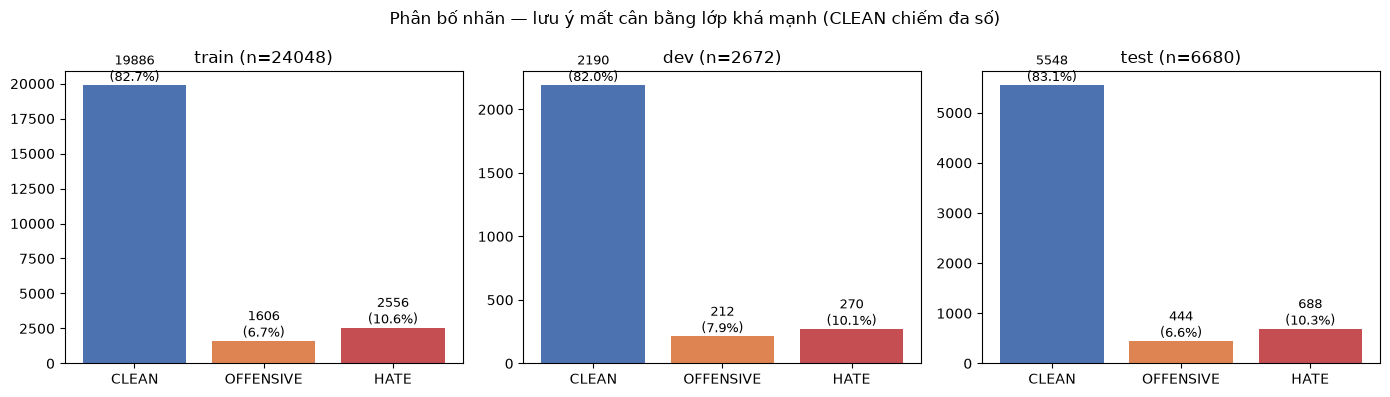

In [92]:
# Phân bố nhãn theo từng tập
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, (name, df) in zip(axes, [("train", train_raw), ("dev", dev_raw), ("test", test_raw)]):
    counts = df["label_id"].map(LABEL_NAMES).value_counts().reindex(["CLEAN", "OFFENSIVE", "HATE"])
    ax.bar(counts.index, counts.values, color=["#4c72b0", "#dd8452", "#c44e52"])
    ax.set_title(f"{name} (n={len(df)})")
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v}\n({v/len(df):.1%})", ha="center", va="bottom", fontsize=9)
plt.suptitle("Phân bố nhãn — lưu ý mất cân bằng lớp khá mạnh (CLEAN chiếm đa số)")
plt.tight_layout()
plt.show()

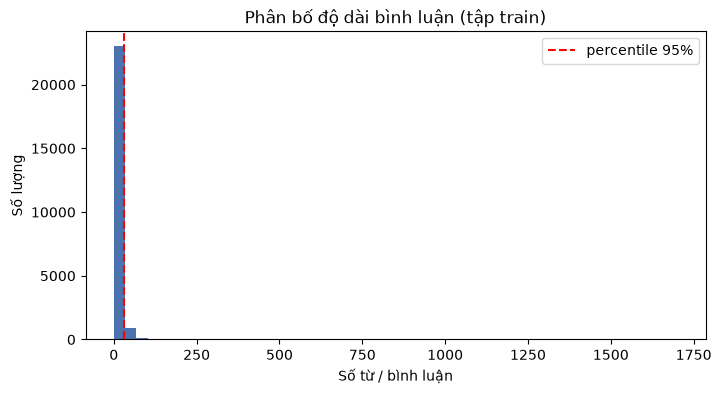

count    24048.000000
mean        11.507527
std         19.963695
min          0.000000
25%          5.000000
50%          8.000000
75%         13.000000
max       1701.000000
Name: free_text, dtype: float64
Percentile 95%: 32.0 | 99%: 60.0


In [93]:
# Phân bố độ dài bình luận (theo số từ, tách đơn giản bằng khoảng trắng)
word_counts = train_raw["free_text"].fillna("").astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
plt.hist(word_counts, bins=50, color="#4c72b0")
plt.axvline(word_counts.quantile(0.95), color="red", linestyle="--", label="percentile 95%")
plt.xlabel("Số từ / bình luận")
plt.ylabel("Số lượng")
plt.title("Phân bố độ dài bình luận (tập train)")
plt.legend()
plt.show()

print(word_counts.describe())
print("Percentile 95%:", word_counts.quantile(0.95), "| 99%:", word_counts.quantile(0.99))

**Nhận xét:** dữ liệu mất cân bằng mạnh (CLEAN ~83%, HATE ~10%, OFFENSIVE ~7%) — cần xử lý bằng
class weighting khi tính loss, và ưu tiên theo dõi **macro-F1** thay vì accuracy khi đánh giá model.
Đa số bình luận khá ngắn (phù hợp đặc trưng bình luận mạng xã hội).

## 4. Tiền xử lý văn bản

Gồm 2 bước:
1. **Làm sạch cơ bản**: bỏ URL, mention, ký tự lặp thừa khoảng trắng, đưa về chữ thường.
2. **Tách từ tiếng Việt (word segmentation)**: PhoBERT được huấn luyện trên văn bản đã tách từ (các từ ghép
   nối bằng `_`, ví dụ `học_sinh`), nên bắt buộc phải tách từ trước khi đưa vào tokenizer của PhoBERT.
   Ở đây dùng `underthesea` (thuần Python, không cần cài Java như VnCoreNLP).

In [94]:
from core.preprocessing import clean_text, segment_text

# Ví dụ minh họa
sample = train_raw["free_text"].iloc[1]
sample_clean = clean_text(sample)
sample_seg = segment_text(sample_clean)
print("Gốc      :", sample)
print("Đã sạch  :", sample_clean)
print("Đã tách từ:", sample_seg)


Gốc      : Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái L :)))
Đã sạch  : đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái l :)))
Đã tách từ: đúng là bọn mắt híp lò_xo thụt :))) bên việt_nam t cái này ra cách đây 10 năm r và bọn t gọi_là cái l :)))


In [95]:
from core.preprocessing import preprocess_df

print("Tiền xử lý train...")
train_df = preprocess_df(train_raw)
print("Tiền xử lý dev...")
dev_df = preprocess_df(dev_raw)
print("Tiền xử lý test...")
test_df = preprocess_df(test_raw)

train_df.head()


Tiền xử lý train...


100%|██████████| 24048/24048 [00:07<00:00, 3059.39it/s]


Tiền xử lý dev...


100%|██████████| 2672/2672 [00:00<00:00, 3101.80it/s]


Tiền xử lý test...


100%|██████████| 6680/6680 [00:02<00:00, 3064.59it/s]


,segmented_text,labels
0,em được làm fan cứng luôn rồi nè ❤_️ reaction ...,0
1,đúng là bọn mắt híp lò_xo thụt :))) bên việt_n...,2
2,đậu văn_cường giờ giống thằng sida hơn à,0
3,côn_đồ cục súc vô_nhân_tính đề_nghi vn . nhà_n...,2
4,từ lý_thuyết đến thực_hành là cả 1 câu_chuyện ...,0


## 5. Tokenize bằng PhoBERT tokenizer

Dùng `AutoTokenizer` của `vinai/phobert-base` (`use_fast=False` vì PhoBERT dùng BPE tuỳ biến, tokenizer chậm
mới tương thích đầy đủ). `MAX_LENGTH` được chọn dựa theo phân vị 95–99% độ dài token thực tế sau khi tokenize.

In [96]:
from transformers import AutoTokenizer

MODEL_NAME = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

sample_lengths = train_df["segmented_text"].sample(3000, random_state=SEED).apply(
    lambda t: len(tokenizer.encode(t))
)
print(sample_lengths.describe())
print("Percentile 95%:", sample_lengths.quantile(0.95), "| 99%:", sample_lengths.quantile(0.99))

count    3000.000000
mean       14.962333
std        12.262369
min         3.000000
25%         8.000000
50%        12.000000
75%        18.000000
max       205.000000
Name: segmented_text, dtype: float64
Percentile 95%: 37.0 | 99%: 66.00999999999976


In [97]:
MAX_LENGTH = 96  # đủ bao phủ >95% bình luận, có thể chỉnh lại theo kết quả cell trên (tối đa 256 với PhoBERT)

from datasets import Dataset, DatasetDict

raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(dev_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False),
})

def tokenize_batch(batch):
    return tokenizer(
        batch["segmented_text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
    )

tokenized_datasets = raw_datasets.map(tokenize_batch, batched=True)
tokenized_datasets.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_datasets

Map: 100%|██████████| 6680/6680 [00:00<00:00, 18835.26 examples/s]


DatasetDict({
    train: Dataset({
        features: ['segmented_text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 24048
    })
    validation: Dataset({
        features: ['segmented_text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2672
    })
    test: Dataset({
        features: ['segmented_text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 6680
    })
})

## 6. Xử lý mất cân bằng lớp & cấu hình huấn luyện

Dùng trọng số lớp (`class_weight="balanced"`) đưa vào `CrossEntropyLoss` thông qua một `Trainer` tuỳ biến
(`WeightedTrainer`), thay vì để loss mặc định coi 3 lớp ngang nhau.

In [98]:
from core.evaluation import compute_class_weights

class_weights = compute_class_weights(train_df["labels"].values)
print("Class weights (CLEAN, OFFENSIVE, HATE):", class_weights)


Class weights (CLEAN, OFFENSIVE, HATE): tensor([0.4031, 4.9913, 3.1362])


In [99]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_weighted": f1_w,
    }

In [100]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=LABEL_NAMES,
    label2id={v: k for k, v in LABEL_NAMES.items()},
)

QUICK_TEST = False  # đặt True để chạy thử nhanh (tập con nhỏ, 1 epoch) trước khi train full

if QUICK_TEST:
    train_split = tokenized_datasets["train"].shuffle(seed=SEED).select(range(2000))
    val_split = tokenized_datasets["validation"].shuffle(seed=SEED).select(range(500))
    num_epochs = 1
else:
    train_split = tokenized_datasets["train"]
    val_split = tokenized_datasets["validation"]
    num_epochs = 4

training_args = TrainingArguments(
    output_dir="../models/phobert-vihsd-checkpoints",
    num_train_epochs=num_epochs,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=0.1,  # float trong [0, 1) = tỷ lệ warmup (transformers>=5.0 gộp warmup_ratio vào warmup_steps)
    eval_strategy="epoch",       # bản transformers cũ hơn dùng tên "evaluation_strategy"
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 34332.40it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing f

## 7. Fine-tune PhoBERT

> Trên CPU/MPS, mỗi epoch với ~24k mẫu có thể mất từ vài phút đến vài chục phút tuỳ cấu hình máy.
> Nếu quá lâu, quay lại cell ở phần 6 và bật `QUICK_TEST = True` để thử nhanh trước.

In [101]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_split,
    eval_dataset=val_split,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

train_result = trainer.train()
train_result

/Users/yongquan/Documents/Master/demo-transformer/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

## 8. Đánh giá chi tiết trên tập test

In [ ]:
test_metrics = trainer.evaluate(tokenized_datasets["test"])
test_metrics

/Users/yongquan/Documents/Master/demo-transformer/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision Macro,Recall Macro,F1 Weighted
0.389143,0.896010,4,0.851048,0.653923,0.628814,0.690032,0.860081


{'eval_loss': 0.8960103988647461,
 'eval_accuracy': 0.8510479041916168,
 'eval_f1_macro': 0.6539234783400404,
 'eval_precision_macro': 0.6288139993902311,
 'eval_recall_macro': 0.6900315195479177,
 'eval_f1_weighted': 0.8600813704087459}

In [ ]:
predictions = trainer.predict(tokenized_datasets["test"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=-1)

from core.evaluation import print_classification_report

print_classification_report(y_true, y_pred, LABEL_NAMES)


/Users/yongquan/Documents/Master/demo-transformer/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

       CLEAN     0.9509    0.9034    0.9265      5548
   OFFENSIVE     0.3746    0.5315    0.4395       444
        HATE     0.5610    0.6352    0.5958       688

    accuracy                         0.8510      6680
   macro avg     0.6288    0.6900    0.6539      6680
weighted avg     0.8724    0.8510    0.8601      6680



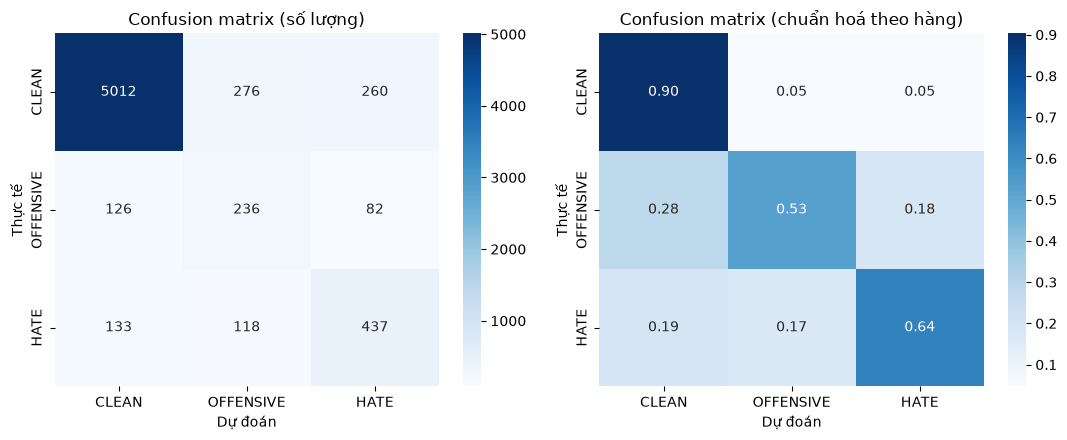

In [ ]:
from core.evaluation import plot_confusion_matrix

plot_confusion_matrix(y_true, y_pred, LABEL_NAMES)


In [ ]:
# Phân tích lỗi: xem thử các bình luận bị phân loại sai (đặc biệt giữa OFFENSIVE và HATE)
from core.evaluation import build_misclassified_report

misclassified_sample = build_misclassified_report(test_raw, y_true, y_pred, LABEL_NAMES, seed=SEED)
misclassified_sample


Tổng số mẫu sai: 995 / 6680 (14.9%)


,free_text,true_label,pred_label
6209,Đảng đã cho ta một mùa xuân đầy thất vọng!,HATE,CLEAN
3453,Trần Huỳnh Như dơ vc,HATE,OFFENSIVE
3736,Khánh Vy tạm gọi là có học nên chính tả không ...,CLEAN,HATE
4379,Trung nút vàng bá dơ,HATE,CLEAN
4202,Vì tết rất ngắn nên ta mới biết quý trọng cái ...,CLEAN,OFFENSIVE
2884,"Loại này nên bắn, đéo cần bịnh hay không.",HATE,OFFENSIVE
5821,K phải khen chứ phim dỡ vkl,OFFENSIVE,CLEAN
4721,Dành Mấy cđl đi soi haha nè :)),CLEAN,OFFENSIVE
1133,Bơm chủ nghĩa dân tộc như bơm ma túy. Càng ngà...,HATE,OFFENSIVE
3998,Bút hình con c,OFFENSIVE,CLEAN


## 9. Lưu model & demo inference

In [ ]:
SAVE_DIR = Path("../models/phobert-vihsd-final")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(SAVE_DIR))
tokenizer.save_pretrained(str(SAVE_DIR))
print("Đã lưu model vào:", SAVE_DIR.resolve())

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.21s/it]

Đã lưu model vào: /Users/yongquan/Documents/Master/demo-transformer/models/phobert-vihsd-final


In [ ]:
def predict_toxicity(text: str) -> dict:
    model.to(device)
    model.eval()

    cleaned = clean_text(text)
    segmented = segment_text(cleaned)
    inputs = tokenizer(
        segmented, return_tensors="pt", truncation=True, max_length=MAX_LENGTH, padding=True
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred_id = int(np.argmax(probs))

    return {
        "text": text,
        "label": LABEL_NAMES[pred_id],
        "probs": {LABEL_NAMES[i]: round(float(probs[i]), 4) for i in range(3)},
    }


samples = [
    "Video này hay quá, cảm ơn bạn đã chia sẻ nhé",
    "Thằng ngu này nói chuyện chán vãi",
    "Bọn mày là lũ súc vật không hơn không kém",
]

for s in samples:
    result = predict_toxicity(s)
    print(f"[{result['label']}] {result['text']}")
    print("   ", result["probs"])

[CLEAN] Video này hay quá, cảm ơn bạn đã chia sẻ nhé
    {'CLEAN': 0.9913, 'OFFENSIVE': 0.004, 'HATE': 0.0047}
[HATE] Thằng ngu này nói chuyện chán vãi
    {'CLEAN': 0.0052, 'OFFENSIVE': 0.0088, 'HATE': 0.9861}
[HATE] Bọn mày là lũ súc vật không hơn không kém
    {'CLEAN': 0.0067, 'OFFENSIVE': 0.0066, 'HATE': 0.9867}


## 10. Kết luận & hướng phát triển

**Tóm tắt:** notebook đã xây dựng pipeline hoàn chỉnh: tải & khám phá dữ liệu ViHSD → tiền xử lý (làm sạch +
tách từ tiếng Việt) → fine-tune PhoBERT với trọng số lớp để xử lý mất cân bằng → đánh giá chi tiết bằng
classification report, confusion matrix và phân tích lỗi.

**Hạn chế:**
- Dữ liệu mất cân bằng mạnh (CLEAN ~83%), lớp OFFENSIVE/HATE dễ bị nhầm lẫn với nhau hơn là với CLEAN.
- Bình luận mạng xã hội có nhiều teencode, viết tắt, sai chính tả — có thể ảnh hưởng đến chất lượng tách từ.
- `underthesea` là lựa chọn thuần Python tiện lợi, nhưng độ chính xác tách từ có thể thấp hơn VnCoreNLP
  (yêu cầu Java) trong một số trường hợp.

**Hướng mở rộng:**
- Thử nghiệm thêm các model khác: `XLM-RoBERTa`, `mBERT`, hoặc các biến thể PhoBERT khác để so sánh.
- Data augmentation cho lớp thiểu số (back-translation, synonym replacement, EDA-augmentation).
- Kết hợp với dataset **ViHOS** (gán nhãn ở mức span) để giải thích được *phần nào* trong câu gây độc hại.
- Tinh chỉnh ngưỡng quyết định (threshold tuning) theo từng lớp thay vì chỉ lấy `argmax`.
- Thử nghiệm ensemble nhiều model hoặc kỹ thuật focal loss thay cho class-weighted cross-entropy.

**Trích dẫn dataset:**

```bibtex
@InProceedings{10.1007/978-3-030-79457-6_35,
  author    = {Luu, Son T. and Nguyen, Kiet Van and Nguyen, Ngan Luu-Thuy},
  title     = {A Large-Scale Dataset for Hate Speech Detection on Vietnamese Social Media Texts},
  booktitle = {Advances and Trends in Artificial Intelligence. Artificial Intelligence Practices},
  year      = {2021},
  publisher = {Springer International Publishing},
  pages     = {415--426}
}
```